# Baseline Method Comparison

This notebook compares `drills`, `ppo`, and `reinforce` from `output/baselines/<version>`.
Artifacts are stored as `{method}/{circuit}/points.csv`.

Each sampled file has one original-circuit row (`run_id` empty) plus 200 samples for every
`(training_seed, evaluation_seed)` pair. A **budget** is the number of samples kept from each
pair, using the smallest `sample_id` values: 10, 50, 100, or 200.

Per-budget tables are built first (`points_by_budget`, `summary_by_budget`,
`aggregate_summary_by_budget`). Set `SELECTED_BUDGET` and rerun the cells below it to refresh
all plots for that budget.

Expected `points.csv` columns:

- `method`, `circuit_name`, `circuit`
- `run_id`, `training_seed`, `evaluation_seed`, `sample_id`
- `size`, `depth`

`run_name` is the method. Each `(training_seed, evaluation_seed)` pair is one evaluation run.


In [11]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`.
The strict hypervolume uses `(1, 1)` as its reference and therefore measures improvements in
both objectives. Extended hypervolume uses `(1.05, 1.05)`, so a front that improves only size
or only depth can have positive dominated area. The original point alone has extended
hypervolume `0.05 * 0.05 = 0.0025`; compare against that baseline rather than interpreting any
positive extended hypervolume as an improvement.


In [12]:
HYPERVOLUME_REFERENCE = (1.0, 1.0)
EXTENDED_HYPERVOLUME_REFERENCE = (1.05, 1.05)
EXTENDED_HYPERVOLUME_ORIGINAL_BASELINE = (
    (EXTENDED_HYPERVOLUME_REFERENCE[0] - 1.0)
    * (EXTENDED_HYPERVOLUME_REFERENCE[1] - 1.0)
)


def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=HYPERVOLUME_REFERENCE):
    """2D minimization hypervolume relative to the supplied reference point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }


def encode_eval_run_id(training_seed, evaluation_seed):
    """Unique integer id for a (training_seed, evaluation_seed) pair."""
    return int(training_seed) * 1000 + int(evaluation_seed)


## Inputs

`points.csv` files are discovered under `output/baselines/<baselines_version>/{method}/{circuit}/`.
`run_name` defaults to the method directory (and the `method` column when present).


In [13]:
baselines_version = "30_08"
BUDGETS = [10, 50, 100, 200]
baselines_dir = Path(f"../output/baselines/{baselines_version}")
points_csv_paths = sorted(
    path for path in baselines_dir.glob("**/*.csv") if path.name == "points.csv"
)
if not points_csv_paths:
    raise FileNotFoundError(f"No points.csv files found under {baselines_dir.resolve()}")

# Optional friendly labels. Missing paths fall back to the method folder / CSV method column.
run_name_overrides = {str(path): path.parent.parent.name for path in points_csv_paths}

print(f"Found {len(points_csv_paths)} points.csv files under {baselines_dir}")
for path in points_csv_paths:
    print(f"  {path} -> {run_name_overrides[str(path)]}")


Found 22 points.csv files under ../output/baselines/30_08
  ../output/baselines/30_08/drills/C1355/points.csv -> drills
  ../output/baselines/30_08/drills/C5315/points.csv -> drills
  ../output/baselines/30_08/drills/adder/points.csv -> drills
  ../output/baselines/30_08/drills/apex1/points.csv -> drills
  ../output/baselines/30_08/drills/bc0/points.csv -> drills
  ../output/baselines/30_08/drills/dalu/points.csv -> drills
  ../output/baselines/30_08/drills/k2/points.csv -> drills
  ../output/baselines/30_08/drills/max/points.csv -> drills
  ../output/baselines/30_08/ppo/C1355/points.csv -> ppo
  ../output/baselines/30_08/ppo/C5315/points.csv -> ppo
  ../output/baselines/30_08/ppo/adder/points.csv -> ppo
  ../output/baselines/30_08/ppo/dalu/points.csv -> ppo
  ../output/baselines/30_08/ppo/k2/points.csv -> ppo
  ../output/baselines/30_08/ppo/max/points.csv -> ppo
  ../output/baselines/30_08/reinforce/C1355/points.csv -> reinforce
  ../output/baselines/30_08/reinforce/C5315/points.csv -

## Load Points And Build Per-Budget Metrics

All CSVs are loaded once. For each budget the first `budget` samples (lowest `sample_id`) are
kept from every `(run_name, circuit, training_seed, evaluation_seed)` group.

- `points_df`: normalized sampled points at that budget
- `summary_df`: one row per `(run_name, training_seed, evaluation_seed, circuit)`
- `aggregate_summary_df`: means/std over evaluation runs, by method and circuit


In [14]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    if run_name is not None:
        df["run_name"] = run_name
    elif "method" in df.columns and df["method"].notna().any():
        df["run_name"] = df["method"].dropna().astype(str).iloc[0]
    else:
        df["run_name"] = path.parent.parent.name

    if "circuit_name" in df.columns:
        named = df["circuit_name"].astype("string")
        fallback = df["circuit"].map(lambda value: Path(str(value)).stem)
        df["circuit"] = named.where(named.notna() & (named.str.len() > 0), fallback)
    else:
        df["circuit"] = df["circuit"].map(lambda value: Path(str(value)).stem)

    for column in ["run_id", "training_seed", "evaluation_seed", "sample_id", "size", "depth"]:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    df["run_id"] = df["run_id"].astype("Int64")
    return df


def aggregate_from_summary(summary_df):
    aggregate_summary_df = (
        summary_df.groupby(["run_name", "circuit"], as_index=False)
        .agg(
            n_runs=("run_id", "nunique"),
            n_training_seeds=("training_seed", "nunique"),
            n_evaluation_seeds=("evaluation_seed", "nunique"),
            n_samples_mean=("n_samples", "mean"),
            hypervolume_mean=("hypervolume", "mean"),
            hypervolume_std=("hypervolume", "std"),
            hypervolume_min=("hypervolume", "min"),
            hypervolume_max=("hypervolume", "max"),
            extended_hypervolume_mean=("extended_hypervolume", "mean"),
            extended_hypervolume_std=("extended_hypervolume", "std"),
            extended_hypervolume_min=("extended_hypervolume", "min"),
            extended_hypervolume_max=("extended_hypervolume", "max"),
            nondominated_mean=("number of nondominated points", "mean"),
            nondominated_std=("number of nondominated points", "std"),
            nondominated_min=("number of nondominated points", "min"),
            nondominated_max=("number of nondominated points", "max"),
        )
    )
    aggregate_summary_df["hypervolume_stderr"] = (
        aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
    )
    aggregate_summary_df["extended_hypervolume_stderr"] = (
        aggregate_summary_df["extended_hypervolume_std"]
        / aggregate_summary_df["n_runs"].pow(0.5)
    )
    aggregate_summary_df["nondominated_stderr"] = (
        aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
    )
    return aggregate_summary_df.sort_values(["circuit", "run_name"]).reset_index(drop=True)


def metrics_for_budget(normalized_points_df, budget):
    ranked = normalized_points_df.sort_values(
        ["run_name", "circuit", "training_seed", "evaluation_seed", "sample_id"]
    )
    points_df = (
        ranked.groupby(
            ["run_name", "circuit", "training_seed", "evaluation_seed"],
            dropna=False,
            group_keys=False,
        )
        .head(budget)
        .copy()
    )
    points_df["budget"] = budget
    points_df["run_id"] = [
        encode_eval_run_id(training_seed, evaluation_seed)
        for training_seed, evaluation_seed in zip(
            points_df["training_seed"], points_df["evaluation_seed"]
        )
    ]

    rows = []
    fronts = {}
    group_keys = ["run_name", "run_id", "training_seed", "evaluation_seed", "circuit"]
    for key, group in points_df.groupby(group_keys, dropna=False):
        run_name, run_id, training_seed, evaluation_seed, circuit = key
        points = list(zip(group["normalized_size"], group["normalized_depth"]))
        front = pareto_front_min(points)
        fronts[(run_name, int(run_id), circuit)] = front
        rows.append(
            {
                "budget": budget,
                "run_name": run_name,
                "run_id": int(run_id),
                "training_seed": int(training_seed),
                "evaluation_seed": int(evaluation_seed),
                "circuit": circuit,
                "n_samples": int(len(group)),
                "hypervolume": hypervolume_min_2d(front, HYPERVOLUME_REFERENCE),
                "extended_hypervolume": hypervolume_min_2d(
                    front, EXTENDED_HYPERVOLUME_REFERENCE
                ),
                "number of nondominated points": len(front),
            }
        )

    summary_df = (
        pd.DataFrame(rows)
        .sort_values(["circuit", "run_name", "training_seed", "evaluation_seed"])
        .reset_index(drop=True)
    )
    aggregate_summary_df = aggregate_from_summary(summary_df)
    aggregate_summary_df.insert(0, "budget", budget)
    return points_df, summary_df, aggregate_summary_df, fronts


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
for column in ["training_seed", "evaluation_seed", "sample_id"]:
    if column not in sample_df.columns:
        raise ValueError(f"Sampled rows are missing required column {column}")
    sample_df[column] = pd.to_numeric(sample_df[column], errors="coerce").astype("Int64")
if sample_df[["training_seed", "evaluation_seed", "sample_id"]].isna().any().any():
    raise ValueError("Sampled rows must have training_seed, evaluation_seed, and sample_id")

normalized_points_df = sample_df.merge(
    initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one"
)
if normalized_points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = normalized_points_df[
        normalized_points_df[["initial_size", "initial_depth"]].isna().any(axis=1)
    ][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for: {missing}")

normalized_points_df["normalized_size"] = (
    normalized_points_df["size"] / normalized_points_df["initial_size"]
)
normalized_points_df["normalized_depth"] = (
    normalized_points_df["depth"] / normalized_points_df["initial_depth"]
)
normalized_points_df["size_reduction"] = 1.0 - normalized_points_df["normalized_size"]
normalized_points_df["depth_reduction"] = 1.0 - normalized_points_df["normalized_depth"]

pair_counts = (
    normalized_points_df.groupby(
        ["run_name", "circuit", "training_seed", "evaluation_seed"], as_index=False
    )
    .size()
    .rename(columns={"size": "n_samples"})
)
coverage = (
    normalized_points_df.groupby(["run_name", "circuit"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
)
print("Methods:", sorted(normalized_points_df["run_name"].unique()))
print("Circuits:", sorted(normalized_points_df["circuit"].unique()))
print("Coverage (method x circuit):")
print(coverage.replace({True: "x", False: ""}).to_string())
print("Samples per (method, circuit, training_seed, evaluation_seed):")
print(pair_counts["n_samples"].value_counts().sort_index().to_string())
print(
    pair_counts.groupby(["run_name", "circuit"], as_index=False)
    .agg(n_eval_runs=("n_samples", "count"), samples_per_run=("n_samples", "min"))
    .to_string(index=False)
)


Methods: ['drills', 'ppo', 'reinforce']
Circuits: ['C1355', 'C5315', 'adder', 'apex1', 'bc0', 'dalu', 'k2', 'max']
Coverage (method x circuit):
circuit   C1355 C5315 adder apex1 bc0 dalu k2 max
run_name                                         
drills        x     x     x     x   x    x  x   x
ppo           x     x     x              x  x   x
reinforce     x     x     x     x   x    x  x   x
Samples per (method, circuit, training_seed, evaluation_seed):
n_samples
200    2200
 run_name circuit  n_eval_runs  samples_per_run
   drills   C1355          100              200
   drills   C5315          100              200
   drills   adder          100              200
   drills   apex1          100              200
   drills     bc0          100              200
   drills    dalu          100              200
   drills      k2          100              200
   drills     max          100              200
      ppo   C1355          100              200
      ppo   C5315          100           

In [15]:
points_by_budget = {}
summary_by_budget = {}
aggregate_summary_by_budget = {}
fronts_by_budget = {}

for budget in BUDGETS:
    points_df_b, summary_df_b, aggregate_summary_df_b, fronts_b = metrics_for_budget(
        normalized_points_df, budget
    )
    points_by_budget[budget] = points_df_b
    summary_by_budget[budget] = summary_df_b
    aggregate_summary_by_budget[budget] = aggregate_summary_df_b
    fronts_by_budget[budget] = fronts_b
    print(
        f"budget={budget:>3}: {len(points_df_b)} points, "
        f"{len(summary_df_b)} eval runs, "
        f"{len(aggregate_summary_df_b)} method-circuit aggregates"
    )

budget_aggregate_df = pd.concat(
    (aggregate_summary_by_budget[budget] for budget in BUDGETS),
    ignore_index=True,
)
budget_summary_df = pd.concat(
    (summary_by_budget[budget] for budget in BUDGETS),
    ignore_index=True,
)
budget_aggregate_df


budget= 10: 22000 points, 2200 eval runs, 22 method-circuit aggregates
budget= 50: 110000 points, 2200 eval runs, 22 method-circuit aggregates
budget=100: 220000 points, 2200 eval runs, 22 method-circuit aggregates
budget=200: 440000 points, 2200 eval runs, 22 method-circuit aggregates


,budget,run_name,circuit,n_runs,n_training_seeds,n_evaluation_seeds,n_samples_mean,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,extended_hypervolume_mean,extended_hypervolume_std,extended_hypervolume_min,extended_hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,extended_hypervolume_stderr,nondominated_stderr
0,10,drills,C1355,100,10,10,10.0,0.070965,0.008576,0.053877,0.081044,0.100416,0.010423,0.079621,0.112558,1.88,0.670896,1,3,0.000858,0.001042,0.067090
1,10,ppo,C1355,100,10,10,10.0,0.080020,0.000895,0.078984,0.081044,0.111403,0.001019,0.110200,0.112558,1.31,0.486069,1,3,0.000090,0.000102,0.048607
2,10,reinforce,C1355,100,10,10,10.0,0.078317,0.005255,0.062500,0.081044,0.109302,0.006380,0.090069,0.112558,1.47,0.576562,1,3,0.000526,0.000638,0.057656
3,10,drills,C5315,100,10,10,10.0,0.069340,0.011538,0.031481,0.092424,0.098256,0.013756,0.052827,0.125538,1.94,0.919156,1,5,0.001154,0.001376,0.091916
4,10,ppo,C5315,100,10,10,10.0,0.070462,0.009047,0.061596,0.085730,0.099546,0.010785,0.088958,0.117613,1.43,0.714284,1,4,0.000905,0.001079,0.071428
5,10,reinforce,C5315,100,10,10,10.0,0.074642,0.006820,0.059177,0.092410,0.104533,0.008098,0.086012,0.125664,1.84,0.849480,1,4,0.000682,0.000810,0.084948
6,10,drills,adder,100,10,10,10.0,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.00,0.000000,1,1,0.000000,0.000000,0.000000
7,10,ppo,adder,100,10,10,10.0,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.00,0.000000,1,1,0.000000,0.000000,0.000000
8,10,reinforce,adder,100,10,10,10.0,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.00,0.000000,1,1,0.000000,0.000000,0.000000
9,10,drills,apex1,100,10,10,10.0,0.096504,0.008380,0.071800,0.112143,0.130216,0.009799,0.101180,0.148491,2.12,0.867831,1,5,0.000838,0.000980,0.086783


## Hypervolume Across Budgets

This uses every precomputed `aggregate_summary_df`. Changing `SELECTED_BUDGET` below does not
affect these plots; rerun the cells above if the CSVs change.


In [16]:
hv_wide = (
    budget_aggregate_df.pivot_table(
        index=["circuit", "run_name"],
        columns="budget",
        values="hypervolume_mean",
    )
    .reset_index()
    .sort_values(["circuit", "run_name"])
)
print("Mean hypervolume by circuit, method, and budget")
hv_wide


Mean hypervolume by circuit, method, and budget


budget,circuit,run_name,10,50,100,200
0,C1355,drills,0.070965,0.077170,0.078454,0.079393
1,C1355,ppo,0.080020,0.080233,0.080366,0.080451
2,C1355,reinforce,0.078317,0.080101,0.080372,0.080806
3,C5315,drills,0.069340,0.077402,0.081334,0.085285
4,C5315,ppo,0.070462,0.071284,0.071840,0.072467
5,C5315,reinforce,0.074642,0.081038,0.085087,0.088999
6,adder,drills,0.000000,0.000000,0.000000,0.000000
7,adder,ppo,0.000000,0.000000,0.000000,0.000000
8,adder,reinforce,0.000000,0.000000,0.000000,0.000000
9,apex1,drills,0.096504,0.107507,0.109997,0.112941


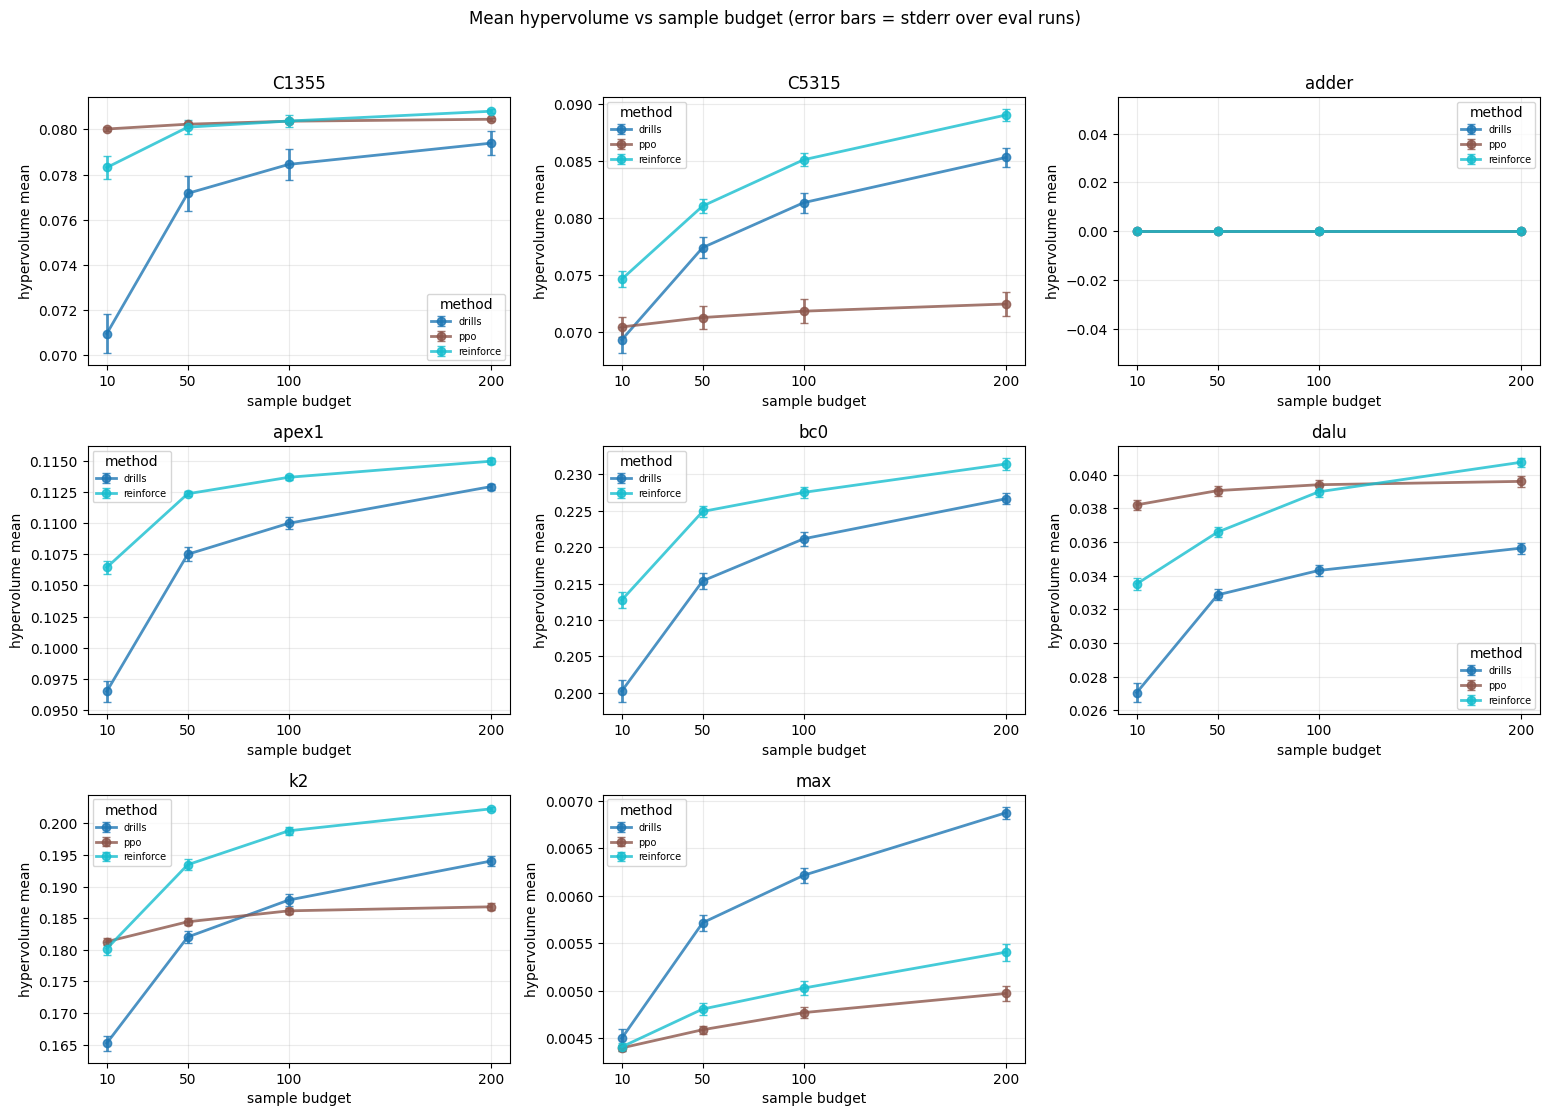

In [18]:
all_circuits = sorted(budget_aggregate_df["circuit"].unique())
all_experiments = sorted(budget_aggregate_df["run_name"].unique())
experiment_cmap = plt.get_cmap("tab10", max(len(all_experiments), 1))
experiment_colors = {
    run_name: experiment_cmap(index)
    for index, run_name in enumerate(all_experiments)
}

n_columns = min(3, len(all_circuits))
n_rows = (len(all_circuits) + n_columns - 1) // n_columns
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.2 * n_columns, 3.8 * n_rows),
    squeeze=False,
)

for ax, circuit in zip(axes.flat, all_circuits):
    present = []
    for run_name in all_experiments:
        curve = budget_aggregate_df[
            (budget_aggregate_df["circuit"] == circuit)
            & (budget_aggregate_df["run_name"] == run_name)
        ].sort_values("budget")
        if curve.empty:
            continue
        present.append(run_name)
        ax.errorbar(
            curve["budget"],
            curve["hypervolume_mean"],
            yerr=curve["hypervolume_stderr"].fillna(0.0),
            color=experiment_colors[run_name],
            marker="o",
            linewidth=2.0,
            capsize=3,
            alpha=.8,
            label=run_name,
        )
    ax.set_title(str(circuit))
    ax.set_xlabel("sample budget")
    ax.set_ylabel("hypervolume mean")
    ax.set_xticks(BUDGETS)
    ax.grid(True, alpha=0.25)
    if present:
        ax.legend(fontsize=7, title="method")

for ax in axes.flat[len(all_circuits):]:
    ax.remove()

fig.suptitle("Mean hypervolume vs sample budget (error bars = stderr over eval runs)", y=0.995)
fig.tight_layout(rect=(0.0, 0.02, 1.0, 0.98))
plt.show()


## Select A Budget

Set `SELECTED_BUDGET` to one of `BUDGETS` and run every cell below this one to refresh the
method comparison for that sample budget.


In [29]:
SELECTED_BUDGET = 10

if SELECTED_BUDGET not in points_by_budget:
    raise KeyError(f"SELECTED_BUDGET={SELECTED_BUDGET} not in {list(points_by_budget)}")

points_df = points_by_budget[SELECTED_BUDGET]
summary_df = summary_by_budget[SELECTED_BUDGET]
aggregate_summary_df = aggregate_summary_by_budget[SELECTED_BUDGET]
fronts = fronts_by_budget[SELECTED_BUDGET]

print(f"Selected budget: {SELECTED_BUDGET} samples per (training_seed, evaluation_seed)")
print("Methods:", sorted(points_df["run_name"].unique()))
print("Circuits:", sorted(points_df["circuit"].unique()))
print(f"points_df rows: {len(points_df)}")
print(f"summary_df rows: {len(summary_df)}")


Selected budget: 10 samples per (training_seed, evaluation_seed)
Methods: ['drills', 'ppo', 'reinforce']
Circuits: ['C1355', 'C5315', 'adder', 'apex1', 'bc0', 'dalu', 'k2', 'max']
points_df rows: 22000
summary_df rows: 2200


## Average Metrics Across Runs

This is `aggregate_summary_df` for `SELECTED_BUDGET`: one row per method and circuit, averaged
over `(training_seed, evaluation_seed)` evaluation runs.


In [20]:
aggregate_summary_df


,budget,run_name,circuit,n_runs,n_training_seeds,n_evaluation_seeds,n_samples_mean,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,extended_hypervolume_mean,extended_hypervolume_std,extended_hypervolume_min,extended_hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,extended_hypervolume_stderr,nondominated_stderr
0,10,drills,C1355,100,10,10,10.0,0.070965,0.008576,0.053877,0.081044,0.100416,0.010423,0.079621,0.112558,1.88,0.670896,1,3,0.000858,0.001042,0.067090
1,10,ppo,C1355,100,10,10,10.0,0.080020,0.000895,0.078984,0.081044,0.111403,0.001019,0.110200,0.112558,1.31,0.486069,1,3,0.000090,0.000102,0.048607
2,10,reinforce,C1355,100,10,10,10.0,0.078317,0.005255,0.062500,0.081044,0.109302,0.006380,0.090069,0.112558,1.47,0.576562,1,3,0.000526,0.000638,0.057656
3,10,drills,C5315,100,10,10,10.0,0.069340,0.011538,0.031481,0.092424,0.098256,0.013756,0.052827,0.125538,1.94,0.919156,1,5,0.001154,0.001376,0.091916
4,10,ppo,C5315,100,10,10,10.0,0.070462,0.009047,0.061596,0.085730,0.099546,0.010785,0.088958,0.117613,1.43,0.714284,1,4,0.000905,0.001079,0.071428
5,10,reinforce,C5315,100,10,10,10.0,0.074642,0.006820,0.059177,0.092410,0.104533,0.008098,0.086012,0.125664,1.84,0.849480,1,4,0.000682,0.000810,0.084948
6,10,drills,adder,100,10,10,10.0,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.00,0.000000,1,1,0.000000,0.000000,0.000000
7,10,ppo,adder,100,10,10,10.0,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.00,0.000000,1,1,0.000000,0.000000,0.000000
8,10,reinforce,adder,100,10,10,10.0,0.000000,0.000000,0.000000,0.000000,0.008725,0.000000,0.008725,0.008725,1.00,0.000000,1,1,0.000000,0.000000,0.000000
9,10,drills,apex1,100,10,10,10.0,0.096504,0.008380,0.071800,0.112143,0.130216,0.009799,0.101180,0.148491,2.12,0.867831,1,5,0.000838,0.000980,0.086783


## Initial vs Optimized Circuit Points

Mean sampled `(size, depth)` at the selected budget, versus the original circuit point.
Each method is shown separately. Arrows go from the original circuit to the mean optimized point.


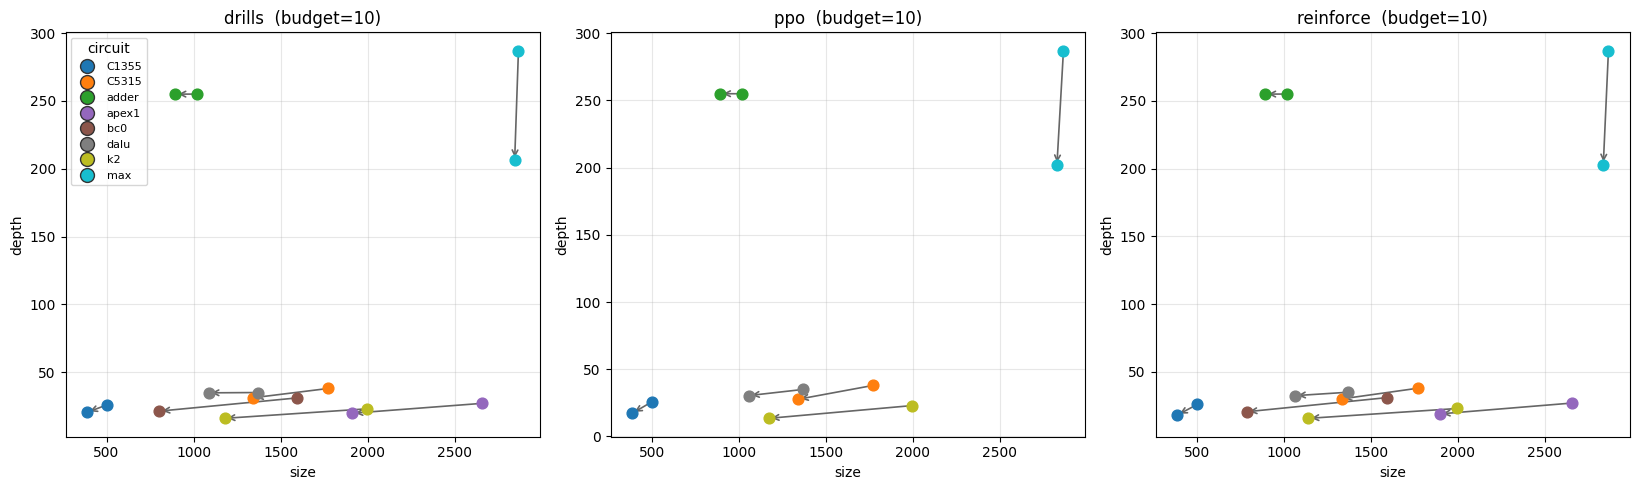

In [21]:
method_circuit_points = (
    points_df[["run_name", "circuit", "size", "depth", "initial_size", "initial_depth"]]
    .groupby(["run_name", "circuit"], as_index=False)
    .agg("mean")
)

methods = sorted(method_circuit_points["run_name"].unique())
n_columns = min(3, max(len(methods), 1))
n_rows = (len(methods) + n_columns - 1) // n_columns
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.5 * n_columns, 5.0 * n_rows),
    squeeze=False,
)

cmap = plt.get_cmap("tab10")
circuit_names = sorted(method_circuit_points["circuit"].unique())
circuit_colors = {
    name: cmap(index / max(len(circuit_names) - 1, 1))
    for index, name in enumerate(circuit_names)
}

for ax, method in zip(axes.flat, methods):
    group_points = method_circuit_points[method_circuit_points["run_name"] == method]
    for _, row in group_points.iterrows():
        color = circuit_colors[row["circuit"]]
        ax.scatter(row["initial_size"], row["initial_depth"], s=60, zorder=3, color=color)
        ax.scatter(row["size"], row["depth"], s=60, zorder=3, color=color)
        ax.annotate(
            "",
            xy=(row["size"], row["depth"]),
            xytext=(row["initial_size"], row["initial_depth"]),
            arrowprops=dict(arrowstyle="->", color="0.4", lw=1.2),
            zorder=2,
        )
    ax.set_xlabel("size")
    ax.set_ylabel("depth")
    ax.set_title(f"{method}  (budget={SELECTED_BUDGET})")
    ax.grid(True, alpha=0.3)

handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=circuit_colors[name],
        markeredgecolor="0.2",
        markersize=10,
        label=name,
    )
    for name in circuit_names
]
axes.flat[0].legend(handles=handles, title="circuit", fontsize=8)

for ax in axes.flat[len(methods):]:
    ax.remove()

fig.tight_layout()
plt.show()


## All Per-Run Pareto Fronts Across Test Circuits

Each panel contains every per-run Pareto front available for that circuit. Runs from the same
method share a color; transparency exposes between-run variability without pooling seeds into
one apparently deterministic front. Lower-left is better.


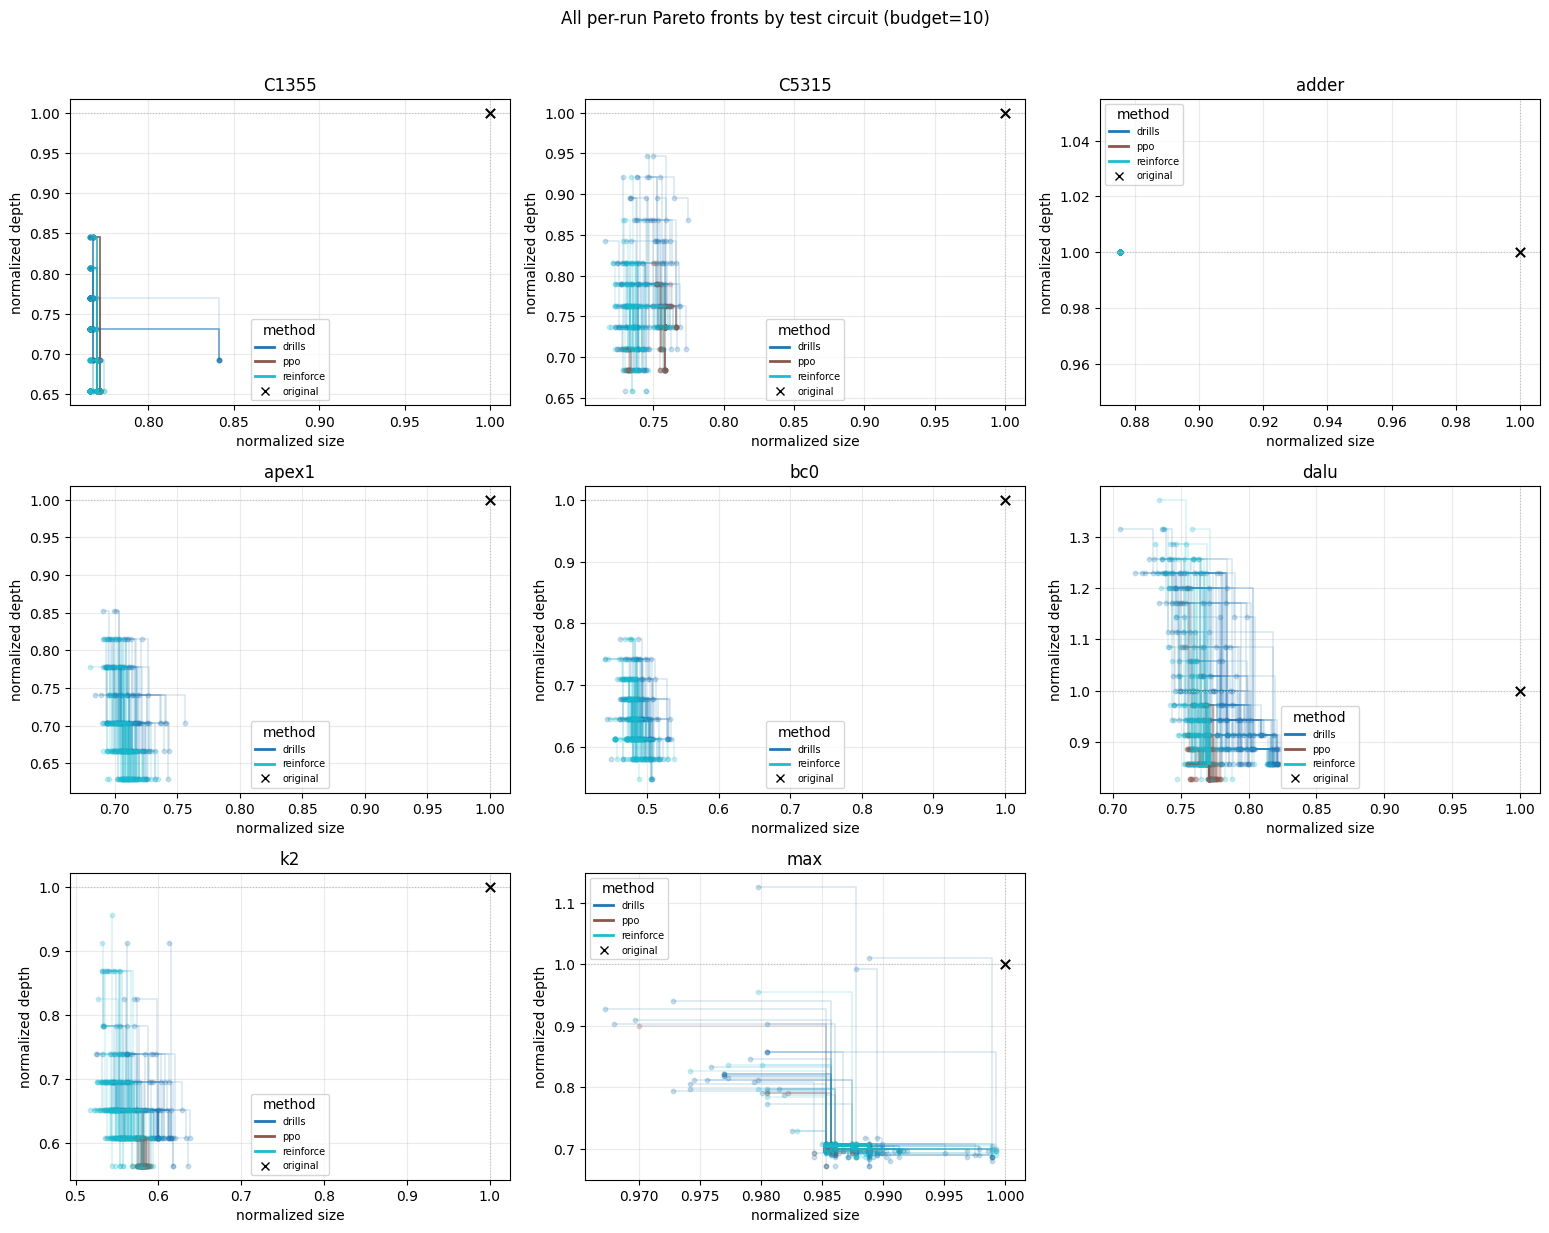

In [22]:
all_circuits = sorted(summary_df["circuit"].unique())
all_experiments = sorted(summary_df["run_name"].unique())
if not all_circuits:
    raise ValueError("No circuits are available to plot.")

experiment_cmap = plt.get_cmap("tab10", max(len(all_experiments), 1))
experiment_colors = {
    run_name: experiment_cmap(index)
    for index, run_name in enumerate(all_experiments)
}

n_columns = min(3, len(all_circuits))
n_rows = (len(all_circuits) + n_columns - 1) // n_columns
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.2 * n_columns, 4.2 * n_rows),
    squeeze=False,
)

for ax, circuit in zip(axes.flat, all_circuits):
    present_experiments = []
    for run_name in all_experiments:
        run_fronts = sorted(
            (
                (run_id, front)
                for (name, run_id, front_circuit), front in fronts.items()
                if name == run_name and front_circuit == circuit and front
            ),
            key=lambda item: item[0],
        )
        if run_fronts:
            present_experiments.append(run_name)
        for run_id, front in run_fronts:
            front_array = np.asarray(sorted(front), dtype=float)
            ax.step(
                front_array[:, 0],
                front_array[:, 1],
                where="post",
                color=experiment_colors[run_name],
                linewidth=1.1,
                alpha=0.18,
            )
            ax.scatter(
                front_array[:, 0],
                front_array[:, 1],
                color=experiment_colors[run_name],
                s=10,
                alpha=0.22,
            )

    ax.scatter([1.0], [1.0], marker="x", s=45, color="black", zorder=5)
    ax.axvline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.axhline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.set_title(str(circuit))
    ax.set_xlabel("normalized size")
    ax.set_ylabel("normalized depth")
    ax.grid(True, alpha=0.25)
    circuit_legend_handles = [
        Line2D([0], [0], color=experiment_colors[name], linewidth=2, label=name)
        for name in present_experiments
    ]
    circuit_legend_handles.append(
        Line2D([0], [0], marker="x", color="black", linestyle="None", label="original")
    )
    ax.legend(handles=circuit_legend_handles, fontsize=7, title="method")

for ax in axes.flat[len(all_circuits):]:
    ax.remove()

fig.suptitle(
    f"All per-run Pareto fronts by test circuit (budget={SELECTED_BUDGET})",
    y=0.995,
)
fig.tight_layout(rect=(0.0, 0.02, 1.0, 0.98))
plt.show()


## Mean Attainment Fronts With Run-Level Confidence Intervals

Pareto fronts do not have naturally corresponding point indices, so directly averaging their
first, second, and third points would be arbitrary. Instead, each run is converted to a
depth-attainment curve: at every normalized-size threshold, the curve records the best depth
attained by that run at or below the threshold. Curves are compared only over the common size
support reached by every run of that method.

The solid line is the pointwise mean attainment curve. The shaded region is a pointwise 95%
percentile confidence interval for that mean, obtained by bootstrapping complete
`(training_seed, evaluation_seed)` runs.


circuit  run_name  n_runs  hypervolume_mean  extended_hypervolume_mean
  C1355    drills     100          0.070965                   0.100416
  C1355       ppo     100          0.080020                   0.111403
  C1355 reinforce     100          0.078317                   0.109302
  C5315    drills     100          0.069340                   0.098256
  C5315       ppo     100          0.070462                   0.099546
  C5315 reinforce     100          0.074642                   0.104533
  adder    drills     100          0.000000                   0.008725
  adder       ppo     100          0.000000                   0.008725
  adder reinforce     100          0.000000                   0.008725
  apex1    drills     100          0.096504                   0.130216
  apex1 reinforce     100          0.106462                   0.141830
    bc0    drills     100          0.200247                   0.248114
    bc0 reinforce     100          0.212743                   0.261880
   dal

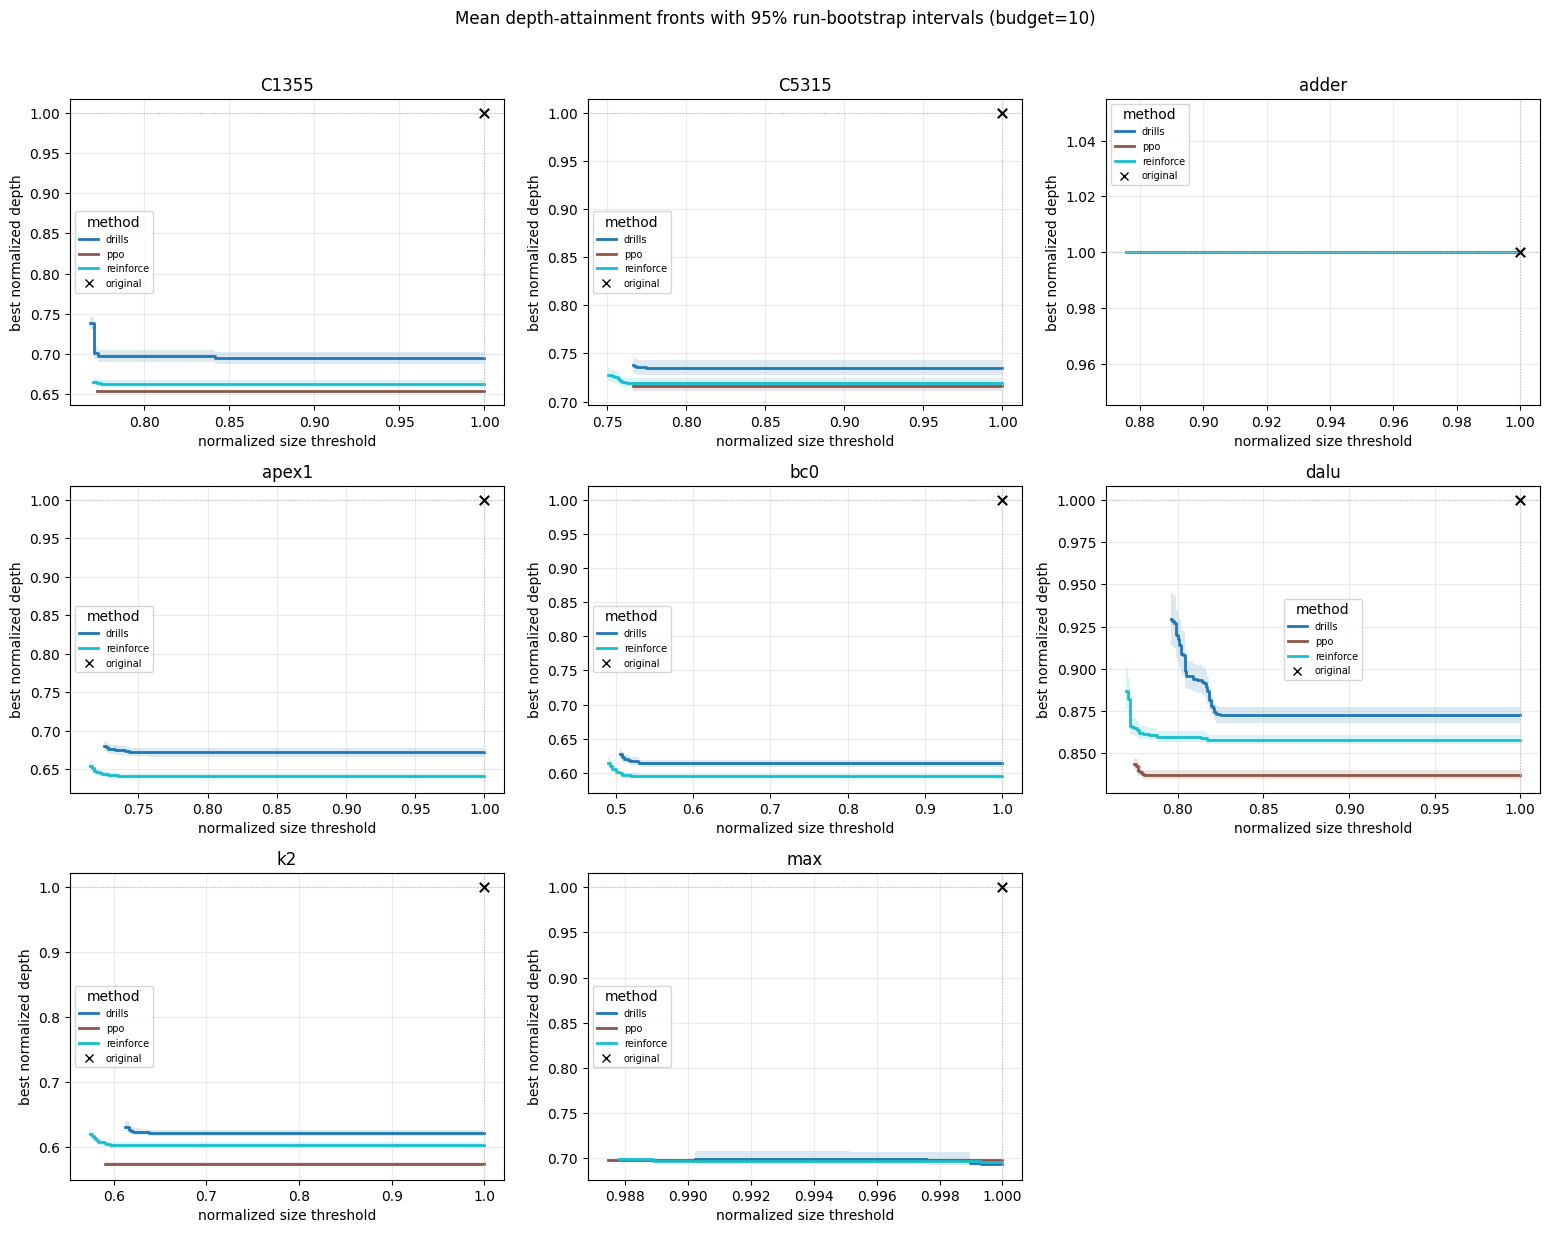

In [23]:
def depth_attainment_curve(front, size_grid):
    """Best normalized depth attained with normalized size <= each threshold."""
    front_array = np.asarray(front, dtype=float)
    curve = np.empty(len(size_grid), dtype=float)
    for index, size_threshold in enumerate(size_grid):
        eligible = front_array[:, 0] <= size_threshold + 1.0e-12
        curve[index] = np.min(front_array[eligible, 1]) if eligible.any() else np.nan
    return curve


def mean_front_with_run_bootstrap(
    run_fronts,
    *,
    grid_size=200,
    n_bootstrap=2000,
    confidence_level=0.95,
    rng,
):
    """Mean depth-attainment front and pointwise run-bootstrap confidence interval."""
    run_fronts = [front for front in run_fronts if front]
    if not run_fronts:
        raise ValueError("At least one non-empty run front is required.")

    common_min_size = max(min(point[0] for point in front) for front in run_fronts)
    max_size = max(1.0, max(max(point[0] for point in front) for front in run_fronts))
    size_grid = np.linspace(common_min_size, max_size, grid_size)
    run_curves = np.vstack(
        [depth_attainment_curve(front, size_grid) for front in run_fronts]
    )
    if np.isnan(run_curves).any():
        raise ValueError("Common-support construction unexpectedly produced missing values.")

    mean_depth = run_curves.mean(axis=0)
    if len(run_curves) < 2:
        ci_low = np.full_like(mean_depth, np.nan)
        ci_high = np.full_like(mean_depth, np.nan)
    else:
        bootstrap_indices = rng.integers(
            0,
            len(run_curves),
            size=(n_bootstrap, len(run_curves)),
        )
        bootstrap_means = run_curves[bootstrap_indices].mean(axis=1)
        tail_probability = (1.0 - confidence_level) / 2.0
        ci_low, ci_high = np.quantile(
            bootstrap_means,
            [tail_probability, 1.0 - tail_probability],
            axis=0,
        )

    return pd.DataFrame(
        {
            "normalized_size": size_grid,
            "mean_normalized_depth": mean_depth,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n_runs": len(run_curves),
        }
    )


mean_front_grid_size = 200
mean_front_bootstrap_repetitions = 2000
mean_front_confidence_level = 0.95
mean_front_rng = np.random.default_rng(42)

mean_front_frames = []
for circuit in all_circuits:
    for run_name in all_experiments:
        experiment_fronts = [
            front
            for (name, _, front_circuit), front in fronts.items()
            if name == run_name and front_circuit == circuit and front
        ]
        if not experiment_fronts:
            continue
        mean_front = mean_front_with_run_bootstrap(
            experiment_fronts,
            grid_size=mean_front_grid_size,
            n_bootstrap=mean_front_bootstrap_repetitions,
            confidence_level=mean_front_confidence_level,
            rng=mean_front_rng,
        )
        mean_front.insert(0, "run_name", run_name)
        mean_front.insert(0, "circuit", circuit)
        mean_front_frames.append(mean_front)

mean_front_df = pd.concat(mean_front_frames, ignore_index=True)
mean_front_run_counts = (
    mean_front_df.groupby(["circuit", "run_name"], as_index=False)["n_runs"]
    .first()
    .merge(
        aggregate_summary_df[
            ["circuit", "run_name", "hypervolume_mean", "extended_hypervolume_mean"]
        ],
        on=["circuit", "run_name"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["circuit", "run_name"])
)
print(mean_front_run_counts.to_string(index=False))

n_columns = min(3, len(all_circuits))
n_rows = (len(all_circuits) + n_columns - 1) // n_columns
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.2 * n_columns, 4.2 * n_rows),
    squeeze=False,
)

for ax, circuit in zip(axes.flat, all_circuits):
    present_experiments = []
    for run_name in all_experiments:
        curve = mean_front_df[
            (mean_front_df["circuit"] == circuit)
            & (mean_front_df["run_name"] == run_name)
        ]
        if curve.empty:
            continue
        present_experiments.append(run_name)
        color = experiment_colors[run_name]
        ax.step(
            curve["normalized_size"],
            curve["mean_normalized_depth"],
            where="post",
            color=color,
            linewidth=2.0,
        )
        if curve["n_runs"].iloc[0] >= 2:
            ax.fill_between(
                curve["normalized_size"],
                curve["ci_low"],
                curve["ci_high"],
                step="post",
                color=color,
                alpha=0.16,
                linewidth=0,
            )

    ax.scatter([1.0], [1.0], marker="x", s=45, color="black", zorder=5)
    ax.axvline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.axhline(1.0, color="0.75", linewidth=0.8, linestyle=":")
    ax.set_title(str(circuit))
    ax.set_xlabel("normalized size threshold")
    ax.set_ylabel("best normalized depth")
    ax.grid(True, alpha=0.25)
    circuit_legend_handles = [
        Line2D([0], [0], color=experiment_colors[name], linewidth=2, label=name)
        for name in present_experiments
    ]
    circuit_legend_handles.append(
        Line2D([0], [0], marker="x", color="black", linestyle="None", label="original")
    )
    ax.legend(handles=circuit_legend_handles, fontsize=7, title="method")

for ax in axes.flat[len(all_circuits):]:
    ax.remove()

fig.suptitle(
    f"Mean depth-attainment fronts with 95% run-bootstrap intervals (budget={SELECTED_BUDGET})",
    y=0.995,
)
fig.tight_layout(rect=(0.0, 0.02, 1.0, 0.98))
plt.show()


## Pairwise Method Comparison

Choose a circuit and a set of methods. Pairwise values are computed over all
`(training_seed, evaluation_seed)` run pairs between two methods and then summarized.


In [24]:
selected_circuit = sorted(points_df["circuit"].unique())[0]
# selected_circuit = "adder"
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())

print("Selected circuit:", selected_circuit)
print("Selected methods:", selected_experiments)
print("Selected budget:", SELECTED_BUDGET)

circ_sum_df = (
    summary_df.loc[
        summary_df["circuit"] == selected_circuit,
        ["run_name", "hypervolume", "extended_hypervolume", "number of nondominated points"],
    ]
    .groupby("run_name")
    .agg("mean")
)
circ_sum_df


Selected circuit: C1355
Selected methods: ['drills', 'ppo', 'reinforce']
Selected budget: 10


,hypervolume,extended_hypervolume,number of nondominated points
run_name,,,
drills,0.070965,0.100416,1.88
ppo,0.080020,0.111403,1.31
reinforce,0.078317,0.109302,1.47


In [25]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)
    source_extended_hypervolumes = [
        hypervolume_min_2d(front, EXTENDED_HYPERVOLUME_REFERENCE)
        for front in source_fronts.values()
    ]
    target_extended_hypervolumes = [
        hypervolume_min_2d(front, EXTENDED_HYPERVOLUME_REFERENCE)
        for front in target_fronts.values()
    ]

    eps_values = []
    dominance_values = []
    for source_front in source_fronts.values():
        for target_front in target_fronts.values():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "budget": SELECTED_BUDGET,
            "n_run_pairs": eps_summary["n"],
            "source_extended_hypervolume_mean": fmean(source_extended_hypervolumes),
            "target_extended_hypervolume_mean": fmean(target_extended_hypervolumes),
            "extended_hypervolume_mean_difference": (
                fmean(source_extended_hypervolumes)
                - fmean(target_extended_hypervolumes)
            ),
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df


,source_run_name,target_run_name,circuit,budget,n_run_pairs,source_extended_hypervolume_mean,target_extended_hypervolume_mean,extended_hypervolume_mean_difference,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,drills,ppo,C1355,10,10000,0.100416,0.111403,-0.010987,0.043619,0.037190,0.000372,0.000000,0.115385,0.275933,0.404392,0.004044,0.0,1.0
1,drills,reinforce,C1355,10,10000,0.100416,0.109302,-0.008886,0.038695,0.036965,0.000370,-0.003968,0.115385,0.312633,0.406447,0.004064,0.0,1.0
2,ppo,drills,C1355,10,10000,0.111403,0.100416,0.010987,0.003075,0.002713,0.000027,-0.001984,0.005952,0.460050,0.469741,0.004697,0.0,1.0
3,ppo,reinforce,C1355,10,10000,0.111403,0.109302,0.002101,0.002481,0.002668,0.000027,-0.003968,0.005952,0.440850,0.481339,0.004813,0.0,1.0
4,reinforce,drills,C1355,10,10000,0.109302,0.100416,0.008886,0.005777,0.014470,0.000145,-0.001984,0.076923,0.600300,0.418763,0.004188,0.0,1.0
5,reinforce,ppo,C1355,10,10000,0.109302,0.111403,-0.002101,0.010270,0.022151,0.000222,0.000000,0.076923,0.608983,0.468494,0.004685,0.0,1.0


## Print Selected Pareto Fronts

This prints a Pareto front for each selected method on the chosen circuit. The front is pooled
across selected runs for that method, then filtered again for nondominated normalized
`(size, depth)` points.


In [26]:
# Choose which eval runs to include in the printed front. None means all runs for each method.
selected_run_ids = None  # example: [0, 1, 2]  (encoded as training_seed * 1000 + evaluation_seed)

front_rows = []
selected_front_summary_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    selected_front_summary_rows.append(
        {
            "run_name": run_name,
            "circuit": selected_circuit,
            "budget": SELECTED_BUDGET,
            "hypervolume": hypervolume_min_2d(pooled_front, HYPERVOLUME_REFERENCE),
            "extended_hypervolume": hypervolume_min_2d(
                pooled_front, EXTENDED_HYPERVOLUME_REFERENCE
            ),
            "number of nondominated points": len(pooled_front),
        }
    )
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "budget": SELECTED_BUDGET,
                "pooled_hypervolume": hypervolume_min_2d(
                    pooled_front, HYPERVOLUME_REFERENCE
                ),
                "pooled_extended_hypervolume": hypervolume_min_2d(
                    pooled_front, EXTENDED_HYPERVOLUME_REFERENCE
                ),
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_summary_df = pd.DataFrame(selected_front_summary_rows).sort_values(
    ["run_name"]
).reset_index(drop=True)
selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}  (budget={SELECTED_BUDGET})")
print(f"Methods: {selected_experiments}")
print("Pooled-front metrics:")
print(selected_front_summary_df.to_string(index=False))
print("Pooled-front points:")
print(selected_front_df.to_string(index=False))
selected_front_summary_df, selected_front_df


Pareto fronts for circuit: C1355  (budget=10)
Methods: ['drills', 'ppo', 'reinforce']
Pooled-front metrics:
 run_name circuit  budget  hypervolume  extended_hypervolume  number of nondominated points
   drills   C1355      10     0.081044              0.112558                              1
      ppo   C1355      10     0.081044              0.112558                              1
reinforce   C1355      10     0.081044              0.112558                              1
Pooled-front points:
 run_name circuit  budget  pooled_hypervolume  pooled_extended_hypervolume  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
   drills   C1355      10            0.081044                     0.112558         0.765873          0.653846        0.234127         0.346154   386     17
      ppo   C1355      10            0.081044                     0.112558         0.765873          0.653846        0.234127         0.346154   386     17
reinforce   C1355      10          

(    run_name circuit  budget  hypervolume  extended_hypervolume  \
 0     drills   C1355      10     0.081044              0.112558   
 1        ppo   C1355      10     0.081044              0.112558   
 2  reinforce   C1355      10     0.081044              0.112558   
 
    number of nondominated points  
 0                              1  
 1                              1  
 2                              1  ,
     run_name circuit  budget  pooled_hypervolume  pooled_extended_hypervolume  \
 0     drills   C1355      10            0.081044                     0.112558   
 1        ppo   C1355      10            0.081044                     0.112558   
 2  reinforce   C1355      10            0.081044                     0.112558   
 
    normalized_size  normalized_depth  size_reduction  depth_reduction  size  \
 0         0.765873          0.653846        0.234127         0.346154   386   
 1         0.765873          0.653846        0.234127         0.346154   386   
 2         

## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected method on the selected circuit in
normalized minimization space. Lower-left is better.


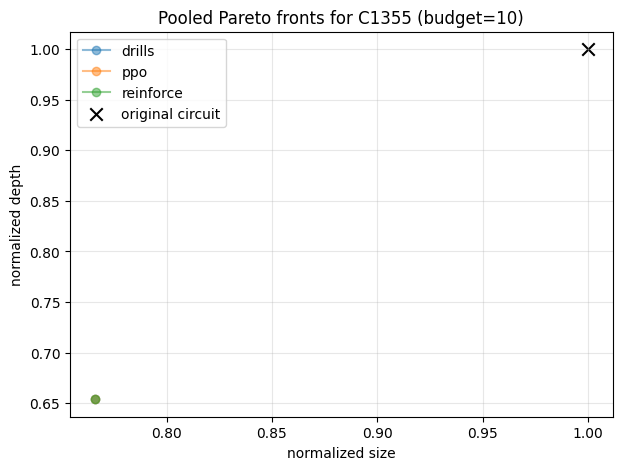

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        alpha=0.5,
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pooled Pareto fronts for {selected_circuit} (budget={SELECTED_BUDGET})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


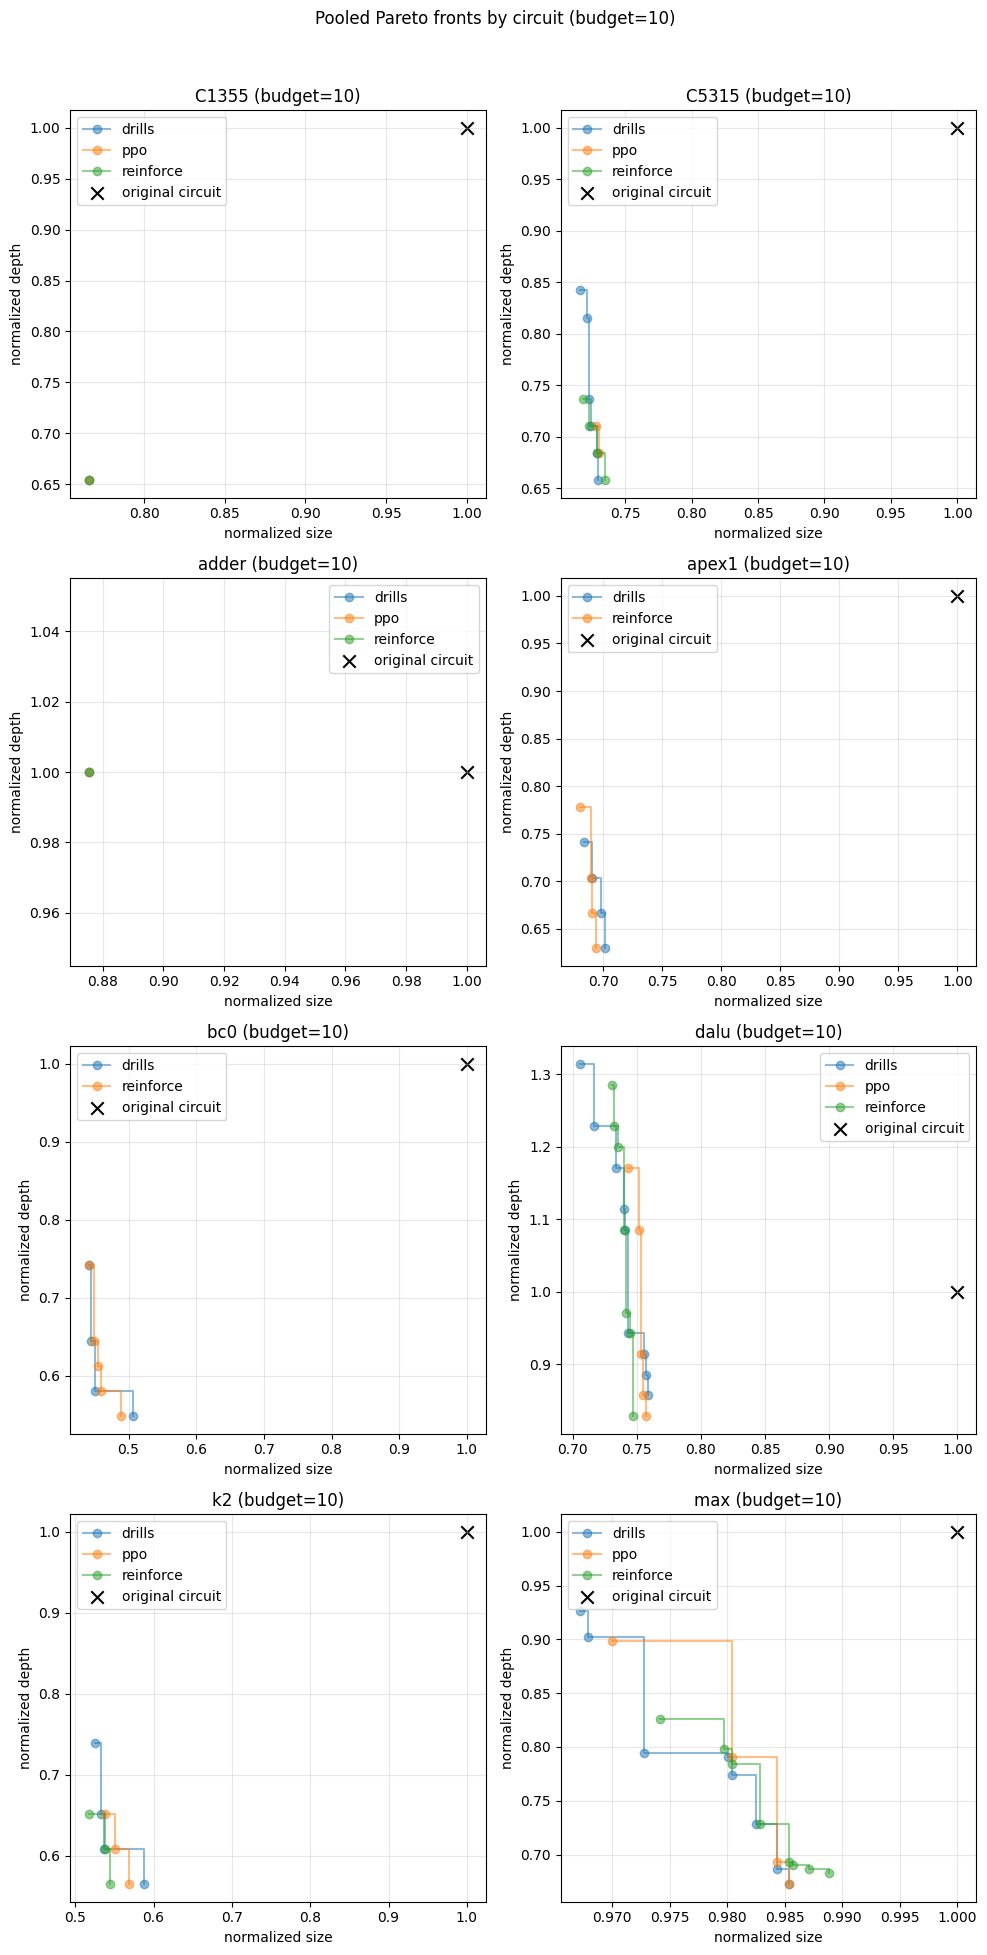

In [28]:
sel_circuits = sorted(points_df["circuit"].unique())
cols = 2
rows = (len(sel_circuits) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)

for circuit, ax in zip(sel_circuits, axes.flatten()):
    cdf = points_df[points_df["circuit"] == circuit]
    for run in sorted(cdf["run_name"].unique()):
        subset = cdf[cdf["run_name"] == run]
        pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
        pooled_front = pareto_front_min(pooled_points)
        front = sorted(pooled_front)
        ax.step(
            [p[0] for p in front],
            [p[1] for p in front],
            where="post",
            marker="o",
            alpha=0.5,
            label=run,
        )

    ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
    ax.set_xlabel("normalized size")
    ax.set_ylabel("normalized depth")
    ax.set_title(f"{circuit} (budget={SELECTED_BUDGET})")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes.flatten()[len(sel_circuits):]:
    ax.remove()

fig.suptitle(f"Pooled Pareto fronts by circuit (budget={SELECTED_BUDGET})", y=0.995)
fig.tight_layout(rect=(0.0, 0.02, 1.0, 0.98))
plt.show()
